<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/Stats_sec_50k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
!pip install pyvis

import pandas as pd
import numpy as np
import json
import os
import glob
import re


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.4 MB/s eta 0:00:00


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

In [2]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure50k.zip

if not os.path.exists('/content/adsync'):
    os.makedirs('/content/adsync')
    print("/content/adsync directory created.")
else:
    print("/content/adsync directory already exists.")

path = "/content/adsync"
!unzip -q secure50k.zip -d /content/adsync

#!mv secure50k.json /content/adsync



data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-08-05 16:04:56--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure50k.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3842228 (3.7M) [application/zip]
Saving to: ‘secure50k.zip’

secure50k.zip       100%[===================>]   3.66M  10.2MB/s    in 0.4s    

2025-08-05 16:04:57 (10.2 MB/s) - ‘secure50k.zip’ saved [3842228/3842228]

/content/adsync directory created.


In [3]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges


df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [4]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))

In [5]:
nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
# edges = edges.drop(columns=['labels'])

In [6]:
edges.head()

,id,labels,properties,type,start,end,label
48286,r_0,NaN,{},relationship,"{'id': '16296', 'labels': ['Base', 'Domain']}","{'id': '16297', 'labels': ['Base', 'OU']}",Contains
48287,r_1,NaN,{},relationship,"{'id': '16296', 'labels': ['Base', 'Domain']}","{'id': '16298', 'labels': ['Base', 'OU']}",Contains
48288,r_2,NaN,{},relationship,"{'id': '16296', 'labels': ['Base', 'Domain']}","{'id': '16299', 'labels': ['Base', 'OU']}",Contains
48289,r_3,NaN,{},relationship,"{'id': '16297', 'labels': ['Base', 'OU']}","{'id': '16300', 'labels': ['Base', 'OU']}",Contains
48290,r_4,NaN,{},relationship,"{'id': '16297', 'labels': ['Base', 'OU']}","{'id': '16301', 'labels': ['Base', 'OU']}",Contains


In [7]:
edges['source'] = edges['start'].apply(lambda x: x.get('id'))
edges['source_node'] = edges['start'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges['target'] = edges['end'].apply(lambda x: x.get('id'))
edges['target_node'] = edges['end'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges = edges.drop(columns=['properties', 'start', 'end', 'id', 'labels'])
edges['id'] = np.arange(len(edges)).astype('int64')
edges = edges.reset_index(drop=True)
nodes['weight'] = 1
edges = edges[['id', 'source', 'source_node', 'target', 'target_node', 'type','label']]
display(edges.head())
edges.info()

,id,source,source_node,target,target_node,type,label
0,0,16296,Domain,16297,OU,relationship,Contains
1,1,16296,Domain,16298,OU,relationship,Contains
2,2,16296,Domain,16299,OU,relationship,Contains
3,3,16297,OU,16300,OU,relationship,Contains
4,4,16297,OU,16301,OU,relationship,Contains


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235668 entries, 0 to 235667
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           235668 non-null  int64 
 1   source       235668 non-null  object
 2   source_node  235668 non-null  object
 3   target       235668 non-null  object
 4   target_node  235668 non-null  object
 5   type         235668 non-null  object
 6   label        235668 non-null  object
dtypes: int64(1), object(6)
memory usage: 12.6+ MB


In [8]:
#edges = edges.drop(columns=['id'])
nodes.info()
nodes.head()

<class 'pandas.core.frame.DataFrame'>
Index: 48286 entries, 0 to 48285
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          48286 non-null  int64 
 1   properties  48286 non-null  object
 2   type        48286 non-null  object
 3   l1          48286 non-null  object
 4   l2          48286 non-null  object
 5   l3          6 non-null      object
 6   weight      48286 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.9+ MB


,id,properties,type,l1,l2,l3,weight
0,16296,"{'domain': 'TESTLAB.LOCALE', 'name': 'TESTLAB....",node,Base,Domain,None,1
1,16297,"{'domain': 'TESTLAB.LOCALE', 'name': 'Admin@TE...",node,Base,OU,None,1
2,16298,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 1 S...",node,Base,OU,None,1
3,16299,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 2@T...",node,Base,OU,None,1
4,16300,"{'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin...",node,Base,OU,None,1


In [9]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 99999


In [10]:
#prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
#display(nodes.tail())

Nodes DataFrame after adding the new record:


In [11]:
print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 15])
# print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 27])
# print(nodes[nodes['id'] == 637])
# print(nodes[nodes['id'] == 581])
# print(nodes[nodes['id'] == 633])
# print(nodes[nodes['id'] == 869])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight]
Index: []


In [12]:
#1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids
tier0_node_ids = []
tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0']
        )
    )
]['id'].tolist()

filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-5[0-9]{2}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == True and
                  x.get('admincount', False) == True
    )
]

len(filtered_nodes)
# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")

print("Updated Tier 0 Node IDs:", tier0_node_ids)

for index, row in nodes.iterrows():
    properties = row['properties']
    node_id = row['id']

    # Check if 'properties' is a dictionary and contains 'distinguishedname'
    if isinstance(properties, dict) and 'distinguishedname' in properties:
        distinguishedname = properties['distinguishedname']

        # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
        if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname or "CN=Administrator," in distinguishedname:
            # Append the id if it's not already in the list
            if node_id not in tier0_node_ids:
                tier0_node_ids.append(node_id)

tier 0 (after checking filtered_nodes): 2668
Updated Tier 0 Node IDs: [16300, 16303, 16304, 16305, 16306, 16383, 16448, 16449, 16453, 16454, 16455, 16457, 16458, 16459, 16460, 16462, 16463, 16469, 16473, 16482, 16484, 16487, 16490, 16499, 16504, 16508, 16514, 16515, 16517, 16521, 16524, 16526, 16527, 16532, 16533, 16534, 16535, 16543, 16544, 16547, 16548, 16556, 16557, 16559, 16560, 16568, 16576, 16577, 16583, 16586, 16588, 16590, 16597, 16600, 16601, 16606, 16609, 16616, 16617, 16622, 16623, 16624, 16626, 16630, 16631, 16637, 16658, 16660, 16672, 16676, 16677, 16679, 16683, 16686, 16692, 16693, 16695, 16696, 16697, 16698, 16702, 16703, 16704, 16708, 16709, 16710, 16711, 16712, 16713, 16723, 16725, 16727, 16739, 16741, 16742, 16746, 16748, 16749, 16750, 16751, 16752, 16754, 16757, 16759, 16761, 16766, 16767, 16774, 16779, 16784, 16787, 16788, 16791, 16794, 16795, 16798, 16799, 16805, 16809, 16812, 16813, 16815, 16819, 16820, 16825, 16826, 16829, 16835, 16845, 16846, 16848, 16849, 16851

In [13]:
tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']

        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))


tier 0  2669
tier 1  4970
tier 2  40783


In [14]:
# Iterate through nodes and add a 'Tier0' column
nodes['Tier0'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier1'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier2'] = 0  # Initialize 'Tier0' column with 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1

# Set 'Tier1' to 1 if node id is in tier1_node_ids
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1

# Set 'Tier2' to 1 if node id is in tier2_node_ids
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# Display the updated nodes DataFrame (optional)
# display(nodes.head())
# display(nodes.tail())

In [15]:
tier0_count = nodes[nodes['Tier0'] == 1].shape[0]
tier1_count = nodes[nodes['Tier1'] == 1].shape[0]
tier2_count = nodes[nodes['Tier2'] == 1].shape[0]

print(f"Number of nodes in Tier 0: {tier0_count}")
print(f"Number of nodes in Tier 1: {tier1_count}")
print(f"Number of nodes in Tier 2: {tier2_count}")

Number of nodes in Tier 0: 2669
Number of nodes in Tier 1: 4970
Number of nodes in Tier 2: 40783


In [16]:
# import pandas as pd

# len(tier0_node_ids)
# tier0_node_ids = pd.DataFrame(tier0_node_ids)

In [17]:

for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5


In [18]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
i=1
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'source': tier0_id,
        'source_node': 'TIER0',
        'target_node': 'TIER0',
        'target': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
#display(edges.tail(266))

Edges DataFrame after adding new TIER0 edges:


In [19]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 2
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head()
#clear_output()
#edges.tail()


Edges_all DataFrame with weight column:


In [20]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
#edges['id'] = np.arange(len(edges)).astype('int64')
#edges.head()
edges['id'] = edges['id'].astype('int64')
edges['source'] = edges['source'].astype('int64')
edges['target'] = edges['target'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')
# edges.info()
# display(edges.head())
# display(edges.tail())

In [21]:
# selected_edges = edges[(edges['source'].isin(tier2_node_ids))  & (edges['target'].isin(tier0_node_ids)) & (~edges['source'].isin(tier0_node_ids)) & (~edges['target'].isin(tier2_node_ids))]
# scratch = selected_edges[selected_edges['weight'] == 8]
# scratch(0)

# df_max_weight =0
# df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
# df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]

In [22]:
tier0_node_ids = pd.DataFrame(tier0_node_ids)
tier2_node_ids = pd.DataFrame(tier2_node_ids)
tier1_node_ids = pd.DataFrame(tier1_node_ids)
tier1_node_ids = tier1_node_ids.rename(columns={0: 'id'})
tier0_node_ids = tier0_node_ids.rename(columns={0: 'id'})
tier2_node_ids = tier2_node_ids.rename(columns={0: 'id'})


In [23]:
# # Check if edges['source'] is contained in tier2_node_ids and count the matches
# count_matching_edges = edges[edges['source'].isin(tier2_node_ids['id'])].shape[0]

# print(f"Number of records where edge['source'] is in tier2_node_ids: {count_matching_edges}")
# tier0_node_ids.info()


In [24]:
selected_edges_t0 = edges[edges['source'].isin(tier2_node_ids['id']) & (edges['target'].isin(tier0_node_ids['id'])) & (~edges['source'].isin(tier0_node_ids['id'])) & (~edges['target'].isin(tier2_node_ids['id']))]
#scratch = selected_edges[selected_edges['weight'] == 8]
print(len(selected_edges_t0))
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]
print(len(selected_nodes))

3257
0


In [25]:
# tier2_node_ids.info()
# len(edges)

# Dijkstra

In [26]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
#for index, row in scratch.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier2_node_ids
    }
    for source, paths in shortest_paths.items()
}
len(shortest_paths_filtered)

# Print the shortest paths (optional)
# for source, paths in shortest_paths_filtered.items():
#   if paths:
#     #print(f"Shortest paths from node {source}:")
#     for target, path in paths.items():
#         #print(f"  To node {target}: {path}")
#         ShortestPath = source, target, path
#        # print(ShortestPath)

3024

In [27]:
#tier2_node_ids = pd.DataFrame(tier2_node_ids)
#

In [28]:
def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    if not edge.empty:
        # Assuming there is only one edge with this start and end for simplicity in path finding
        # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
        return edge.iloc[0]['weight']

#     if not edge.empty:
# # Return the weight from the resulting DataFrame
#         return edge['weight'].values[0]
#     else:
#         return None

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
#            get_edge_weight(source, target)
            shortest_paths_list.append({
                'source': int(source),
                'target': int(target),
                'path': path,
                'weight': get_edge_weight(source, target)
            })

# Convert the list of dictionaries to a DataFrame
#shortest_paths_list = pd.DataFrame(shortest_paths_list)

# #shortest_paths_list.info()
# #short = shortest_paths_list[shortest_paths_list['target'].isin(tier2_node_ids)]
# #short1 = short[~short['source'].isin(tier0_node_ids)]
# #len(short)

In [29]:
# shortest_paths_list = pd.DataFrame(shortest_paths_list)
# shortest_paths_list.info()

In [30]:
#tier0_node_ids.info()

In [31]:
display(edges[edges['source'] == 286])

,id,source,source_node,target,target_node,type,label,weight


In [32]:
import pandas as pd
shortest_paths_list = pd.DataFrame(shortest_paths_list)
#short= shortest_paths_list[shortest_paths_list['source'] isin tier2_node_ids]

#tier2_node_ids = pd.DataFrame(tier2_node_ids)

def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    # if not edge.empty:
    #     # Assuming there is only one edge with this start and end for simplicity in path finding
    #     # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
    return edge.iloc[0]['weight']

# Calculate the total weight for each shortest path

shortest_paths_with_weight = []

# Iterate through the DataFrame 'short1' using 'iterrows()'
for index, path_info in shortest_paths_list.iterrows():
    total_weight = 0
# The path is expected to be a list of node IDs
    path = path_info['path']
    source = path_info['source']
    target = path_info['target']

# Ensure that 'path' is a list; you may need to adjust this if 'path' is a string
    if isinstance(path, list):
    # Iterate through the path to get the edges
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i + 1]
        # Assuming you have a way to get the weight of the edge between start_node and end_node
        # For example, if you have a function or a mapping for edge weights
            edge_weight = get_edge_weight(start_node, end_node) # Define this function to retrieve the weight
            total_weight += edge_weight
            shortest_paths_with_weight.append({'source': source, 'target': target, 'path': path, 'total_weight': total_weight})

# Append the result (path and its total weight) to the list
#shortest_paths_with_weight.append({source: source, target: target, path: path, 'total_weight': total_weight})

df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight).copy()
#df_shortest_paths_with_weight = df1[(df1['target'].isin(tier0_node_ids)) ]#& (df1['source'].isin(tier2_node_ids)) & (~df1['source'].isin(tier0_node_ids)) & (~df1['target'].isin(tier2_node_ids))]
#d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]
# At this point, shortest_paths_with_weight will contain all paths and their corresponding weights
len(df_shortest_paths_with_weight)

3257

In [33]:
# nodevalue = 5262
# is_in_tier2 = nodevalue in tier2_node_ids.values
# print(f"Does tier2_node_ids contain {nodevalue}: {is_in_tier2}")

In [34]:
# type(tier2_node_ids)
# type(tier2_node_ids[0])
# df1.info()

In [35]:
# edges = edges.reset_index(drop=True)
# edges.head()

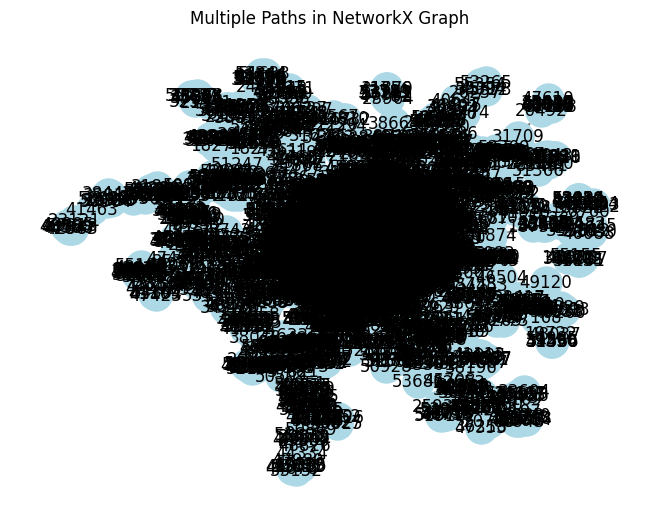

In [36]:
import networkx as nx
import matplotlib.pyplot as plt

df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]


# Example: multiple paths as lists of nodes
#paths = df_min_weight_paths['path']
paths = df_max['path']
# Create an empty graph
G = nx.DiGraph()

# Add edges from all paths
for path in paths:
# Add edges for consecutive pairs of nodes in the path
    edges_G = list(zip(path[:-1], path[1:]))
    G.add_edges_from(edges_G)

# Draw the graph
pos = nx.spring_layout(G, scale=2,k=0.85, iterations=50) # Layout algorithm for positions
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

# Optionally highlight each path in a different colour
# colors = ['red', 'green', 'blue', 'purple']
# for path, color in zip(paths, colors):
#     edges_zip = list(zip(path[:-1], path[1:]))
#     nx.draw_networkx_edges(G, pos, edgelist=edges_zip, width=2) #edge_color=color, width=2)
#plt.figure(figsize=(12, 8))
plt.title("Multiple Paths in NetworkX Graph")
plt.show()

In [37]:
len(tier0_node_ids)

2669

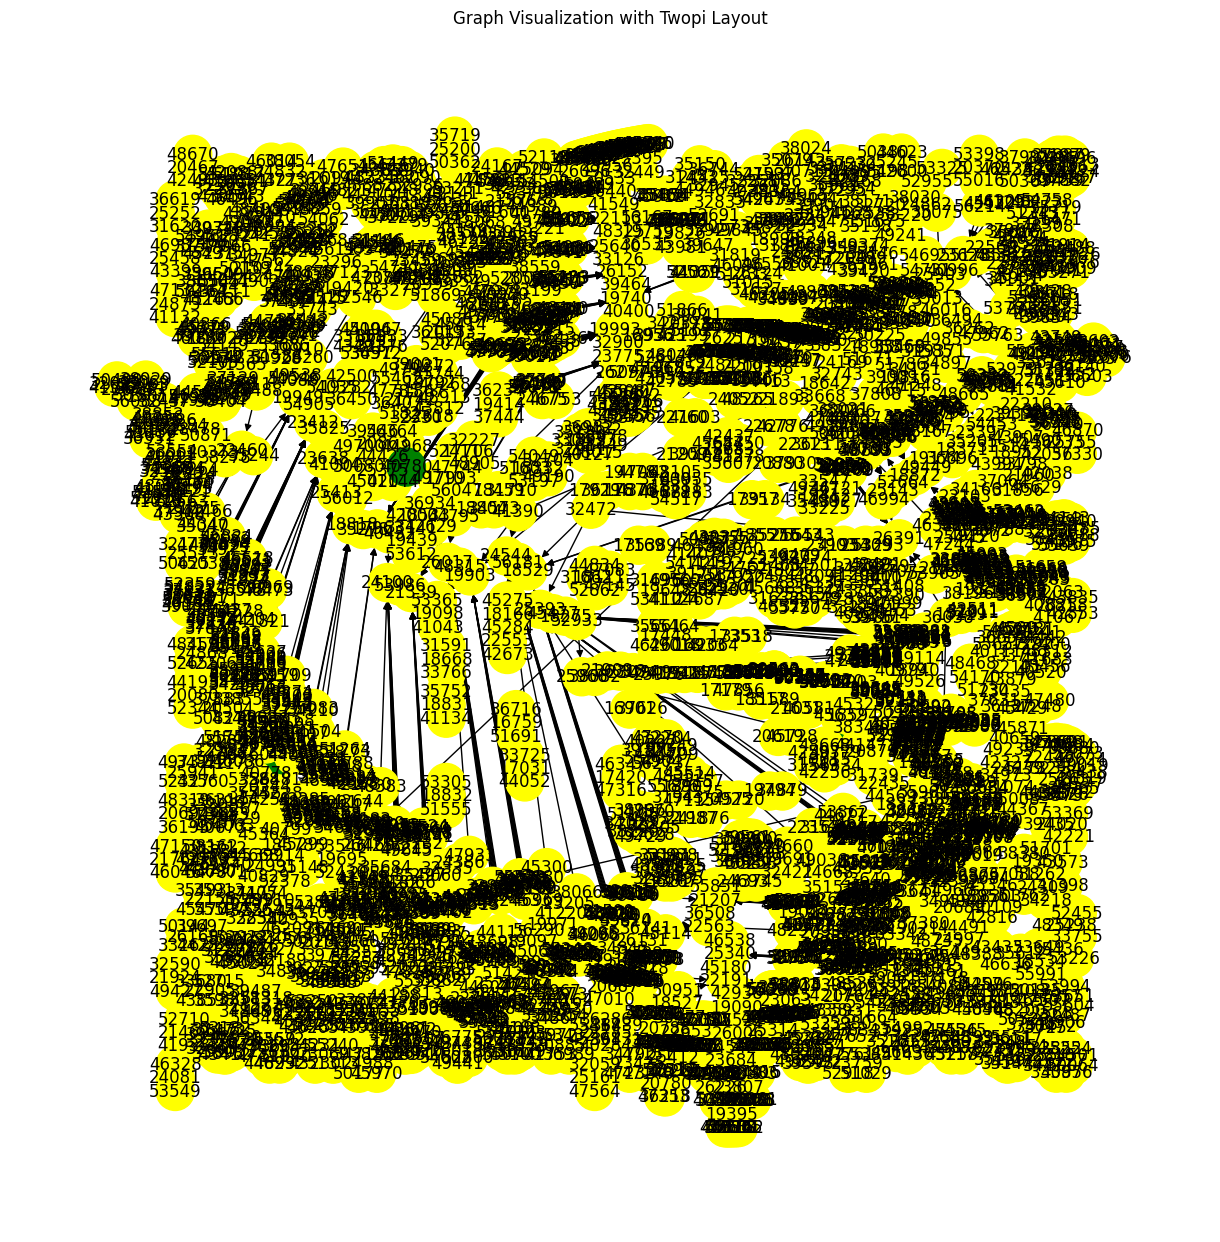

In [38]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight
# df_max1 = []

# df_max1 = df[(df['source'].isin(tier2_node_ids))]# & (df['target'].isin(tier0_node_ids))]

# df_max_weight =0
# df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
# df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]
#d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]

df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df[(df['total_weight'] == df_max_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]

#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if (node) in str(tier0_node_ids['id']):
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        label ='Tier0'
        height=4
    elif (node) in tier1_node_ids['id']:
        colors.append('orange')
        height=2
    elif (node) in str(tier2_node_ids['id']):
        colors.append('green')
        height=1
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
# G.graph['ranksep'] = '1.0' # Increase separation between ranks
# G.graph['nodesep'] = '4.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi")#, root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=750, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name_max = suf + '_max_twopi_graph.pdf'
plt.savefig(graph_name_max, format="pdf")
plt.show()

In [39]:
# import networkx as nx
# import pydot
# import matplotlib.pyplot as plt
# from networkx.drawing.nx_pydot import *
# # graphviz is installed already, but need lib too
# #!apt install libgraphviz-dev
# #!pip install pygraphviz
# # import pygraphviz as G_pgv

# df=df_shortest_paths_with_weight
# # df_max1 = []

# # df_max1 = df[(df['source'].isin(tier2_node_ids))]# & (df['target'].isin(tier0_node_ids))]

# df_min_weight =0
# df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
# df_min = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]
# #d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]

# #df.columns = ["source", "target", "path", "weight"]
# #sample = df.sample(500, random_state = 1)
# #sample.head(10)

# G = nx.DiGraph()
# #graph [root=new_node_id label=twopi]

# for index, row in df_min.iterrows():
#     source = row['source']
#     target = row['target']
#     path = row['path']
#     weight = row['total_weight']

#     # Add nodes for all nodes in the path
#     for node in path:
#         G.add_node(str(node))

#     # Add edges for consecutive nodes in the path
#     for i in range(len(path) - 1):
#         G.add_edge(str(path[i]), str(path[i+1]))
# colors = []
# #Assuming node 4 is the one to highlight
# for node in G.nodes():
#     if (node) in str(tier0_node_ids['id']):
#     #== new_node_id : # Ensure comparison is with string if nodes are strings
#         colors.append('red')
#         label ='Tier0'
#         height=4
#     elif (node) in tier1_node_ids['id']:
#         colors.append('orange')
#         height=2
#     elif (node) in str(tier2_node_ids['id']):
#         colors.append('green')
#         height=1
#     else:
#         colors.append('yellow')

# # Set graph attributes to control spacing
# # G.graph['ranksep'] = '1.0' # Increase separation between ranks
# # G.graph['nodesep'] = '4.0' # Increase separation between nodes

# #G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
# #G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
# plt.figure(figsize=(12, 12))
# # Use pydot_layout with 'twopi' program
# pos = pydot_layout(G, prog="twopi")#, root=str(new_node_id)) # Removed root as it might not exist in the graph
# nx.draw(G, pos, node_color=colors, with_labels=True, node_size=750, font_weight='normal')

# plt.title("Graph Visualization with Twopi Layout")
# graph_name_max = suf + '_min_twopi_graph.pdf'
# plt.savefig(graph_name_max, format="pdf")
# plt.show()

In [40]:
print(nodes[nodes['id'] == 3167])
print(nodes[nodes['id'] == 3366])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


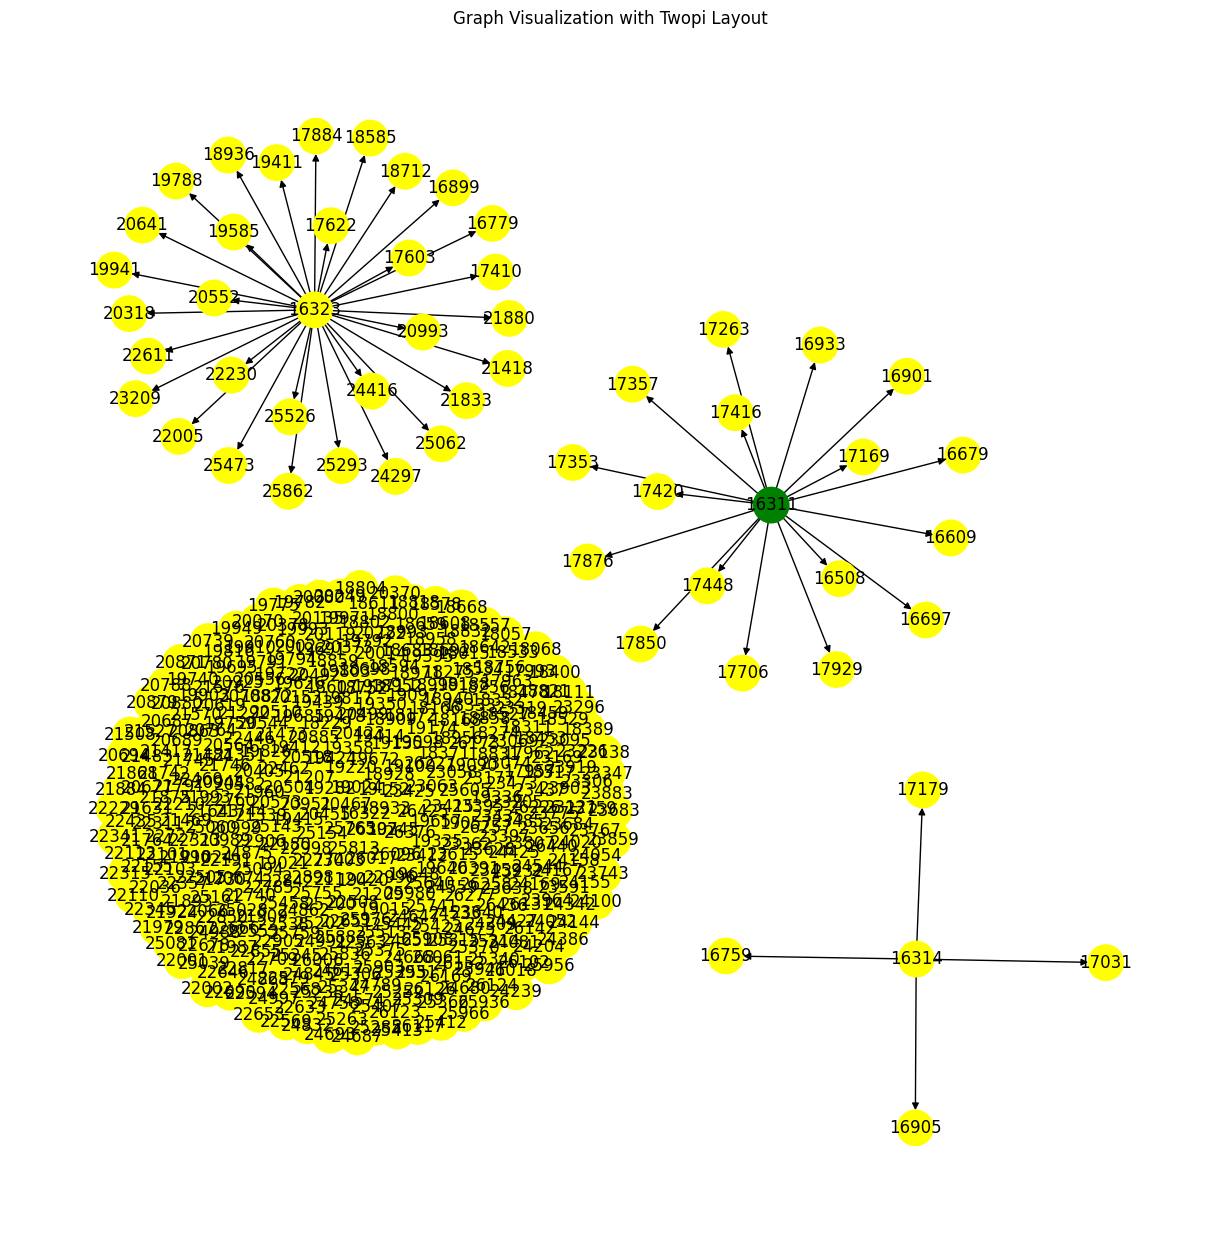

In [57]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight

df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]



G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if (node) in str(tier0_node_ids['id'].values):
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        height=6
    elif (node) in str(tier1_node_ids['id'].values):
        colors.append('orange')
        height=4
    elif (node) in str(tier2_node_ids['id'].values):
        colors.append('green')
        height=2
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0' # Increase separation between ranks
G.graph['nodesep'] = '3.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
#Options depend on GraphViz version but may include: ‘dot’, ‘twopi’, ‘fdp’, ‘sfdp’, ‘circo’
pos = pydot_layout(G, prog="sfdp", root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name = suf + '_min_twopi_graph.pdf'
plt.savefig(graph_name, format="pdf")
plt.show()


In [42]:
print(nodes[nodes['id'] == 3167])
print(nodes[nodes['id'] == 3366])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


In [43]:
# admin_nodes = nodes[
#     nodes['properties'].apply(
#         lambda x: isinstance(x, dict) and 'name' in x and 'administrator' in x['name'].lower()
#     )
# ]
# display(admin_nodes)

In [44]:

edges.head()

,id,source,source_node,target,target_node,type,label,weight
0,0,16296,Domain,16297,OU,relationship,Contains,2
1,1,16296,Domain,16298,OU,relationship,Contains,2
2,2,16296,Domain,16299,OU,relationship,Contains,2
3,3,16297,OU,16300,OU,relationship,Contains,2
4,4,16297,OU,16301,OU,relationship,Contains,2


In [45]:
# df_shortest_paths_with_weight.info()


# tier2_node_ids1 = [int(node_id) for node_id in tier2_node_ids]
# print(f"Type of elements in tier2_node_ids after conversion: {type(tier2_node_ids1[0]) if tier2_node_ids else 'List is empty'}")

In [46]:
print(nodes[nodes['id'] == 6247])
print(nodes[nodes['id'] == 6248])
print(nodes[nodes['id'] == 6236])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])


Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


# secure50k_min_graph.html
{suf}

In [47]:
import pandas as pd
from pyvis.network import Network
#pyvis.__version__

#Loading the data
#data = pd.read_csv("facebook_combined.txt", sep=" ", header=None)
df=df_shortest_paths_with_weight


df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]
p0 = df_min.shape[0]

net = Network(notebook = True, cdn_resources = "in_line",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True
)
net.repulsion()
for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='red') # Changed color to red for Tier 0
      elif node in tier1_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')


    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        lbl = " " + str(path[i]) + "->" +str(path[i+1])
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight},{lbl}") # Added weight and title to edge#suf="vul1k"
graph_name = suf + '_min_graph.html'
net.show(graph_name)

secure50k_min_graph.html


# secure50k_max_graph.html

In [48]:
df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df[(df['total_weight'] == df_max_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]
p1 = df_max.shape[0]



#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True
)
net.repulsion()

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    for node in path:
      if node in tier0_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='red') # Changed color to red for Tier 0
      elif node in tier1_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')


    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        lbl = str(path[i]) + "->" +str(path[i+1])
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight},{lbl}") # Added weight and title to edge
graph_name = suf + '_max_graph.html'
net.show(graph_name)

secure50k_max_graph.html


# New section

# New section

In [ ]:
for index, row in df_max.iterrows():
    path = row['path']
    print(f"Path: {path}")
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            # Get the properties and check for 'name' and Tier information
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = node_info.iloc[0]['Tier0'] == 1
            is_tier1 = node_info.iloc[0]['Tier1'] == 1
            is_tier2 = node_info.iloc[0]['Tier2'] == 1
            print(f"  Node ID: {node_id}, Name: {node_name}, Tier0: {is_tier0}, Tier1: {is_tier1}, Tier2: {is_tier2}")
        else:
            print(f"  Node ID: {node_id} not found in nodes DataFrame.")
    print("-" * 20)

In [50]:
filtered_shortest_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == 1]
display(filtered_shortest_paths)

,source,target,path,total_weight


In [ ]:
# Create a list to store the data for the table
table_data = []

# Iterate through the paths in df_max
for index, row in df_max.iterrows():
    path = row['path']
    # path_str = " -> ".join(map(str, path)) # Convert the path list to a string

    # Iterate through the nodes in the current path
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = 1 if node_info.iloc[0]['Tier0'] == 1 else 0
            is_tier1 = 1 if node_info.iloc[0]['Tier1'] == 1 else 0
            is_tier2 = 1 if node_info.iloc[0]['Tier2'] == 1 else 0

            # Append the data as a dictionary to the list
            table_data.append({
                'Node Id': node_id, # Changed 'path' to 'Node Id' and stored node_id
                'Name': node_name,
                'Tier 0': is_tier0,
                'Tier 1': is_tier1,
                'Tier 2': is_tier2
            })

# Create a pandas DataFrame from the list of dictionaries
df_path_info = pd.DataFrame(table_data)

# Display the DataFrame
display(df_path_info)

In [52]:
latex_table = df_path_info.to_latex(index=False)

file_name = suf + "_max_paths_table.tex"

with open(file_name, 'w') as f:
    f.write(latex_table)

print(f"Table exported to {file_name}")

Table exported to secure50k_max_paths_table.tex


In [53]:
# count_weight_2 = selected_edges[selected_edges['weight'] == 2].shape[0]
# print(f"Number of records in selected_edges with weight == 2: {count_weight_2}")

In [54]:
# weight_distribution = selected_edges['weight'].value_counts().sort_index()
# print("Distribution of weights in selected_edges:")
# print(weight_distribution)

In [58]:
from collections import Counter
#tier0_node_ids = tier0_node_ids.rename(columns={0: 'id'})

l1 = len(tier0_node_ids)
l2 = len(tier1_node_ids)
l3 = len(tier2_node_ids)
ln1 = len(nodes) -1
other =((ln1 - (l1 + l2 + l3)) / ln1 * 100)#,3)

amount_of_tier0_nodes = (l1 / ln1 * 100)#,3)
print(f"% amount of tier0 nodes: {amount_of_tier0_nodes} %" )

amount_of_tier1_nodes = (l2 /  ln1 * 100)#,3)
print(f"% amount of tier1 nodes: {amount_of_tier1_nodes} %" )

amount_of_tier2_nodes = (l3 /  ln1 * 100)#,3)
print(f"% amount of tier2 nodes: {amount_of_tier2_nodes} %" )
tot = amount_of_tier2_nodes + amount_of_tier1_nodes + amount_of_tier0_nodes + other
print(f"% amount of total nodes: {tot} %" )


cnt_min_paths = round(p0 / ln1 * 100,3)
cnt_max_paths = round(p1 / ln1 * 100,3)

print(f"amount of min paths: {p0}: {cnt_min_paths} %" )
print(f"amount of max paths: {p1}: {cnt_max_paths} %" )

stats_data = {
    "amount_of_tier0_nodes_percent": round(amount_of_tier0_nodes, 3),
    "amount_of_tier1_nodes_percent": round(amount_of_tier1_nodes, 3),
    "amount_of_tier2_nodes_percent": round(amount_of_tier2_nodes, 3),
    "amount_of_other_nodes_percent": round(other, 3),
    "total_nodes_percent": round(tot, 3),
    "amount_of_min_paths": p0,
    "percent_of_min_paths": cnt_min_paths,
    "amount_of_max_paths": p1,
    "percent_of_max_paths": cnt_max_paths
}

# Create the filename
file_name = suf + "_stats.json"

# Save the dictionary as a JSON file
with open(file_name, 'w') as f:
    json.dump(stats_data, f, indent=4)

print(f"Statistics exported to {file_name}")
################################################################

# l2_counts = Counter(nodes['l2'])
# display(l2_counts)
l2_counts = Counter(nodes['l2'])

# Create a DataFrame from the Counter
l2_counts_df = pd.DataFrame(l2_counts.items(), columns=['Value', 'Count'])
l2_counts_df = l2_counts_df.sort_values(by='Count')

# Convert the DataFrame to a LaTeX table format
latex_table = l2_counts_df.to_latex(index=False)

# Display the LaTeX table output
print(latex_table)

###############################################################


% amount of tier0 nodes: 5.527482085904817 %
% amount of tier1 nodes: 10.292838503914178 %
% amount of tier2 nodes: 84.46133454831627 %
% amount of total nodes: 100.0 %
amount of min paths: 468: 0.969 %
amount of max paths: 2789: 5.776 %
Statistics exported to secure50k_stats.json
\begin{tabular}{lr}
\toprule
Value & Count \\
\midrule
Domain & 1 \\
Container & 1 \\
ALL_T0 & 1 \\
GPO & 41 \\
OU & 48 \\
Group & 8181 \\
User & 15005 \\
Computer & 25009 \\
\bottomrule
\end{tabular}



In [ ]:
l2_counts = nodes['l2'].value_counts().to_dict()

# Create the filename
file_name = suf + "stats.json"

# Save the unique values and counts as JSON
with open(file_name, 'w') as f:
    json.dump(l2_counts, f, indent=4)

print(f"Unique 'l2' values with counts exported to {file_name}")

In [59]:
# Get unique values from the 'l2' column with their counts
l2_counts = nodes['l2'].value_counts().to_dict()

# Create the filename
file_name = suf + "_nodes.json"

# Save the unique values and counts as JSON
with open(file_name, 'w') as f:
    json.dump(l2_counts, f, indent=4)

print(f"Unique 'l2' values with counts exported to {file_name}")

Unique 'l2' values with counts exported to secure50k_nodes.json


In [60]:
# Get unique values from the 'label' column with their counts
label_counts = edges['label'].value_counts().to_dict()

# Create the filename
file_name = suf + "_label.json"

# Save the unique values and counts as JSON
with open(file_name, 'w') as f:
    json.dump(label_counts, f, indent=4)

print(f"Unique 'label' values with counts exported to {file_name}")

Unique 'label' values with counts exported to secure50k_label.json


In [ ]:
count_matching_edges = edges[edges['source'].isin(tier2_node_ids['id'])]
print(f"Number of records where edge['source'] is in tier2_node_ids: {count_matching_edges}")

In [ ]:
# edges[edges['id'] == 21316]
# #edges.tail(150)
# tier2 = tier2_node_ids[tier2_node_ids['id'] == 5388]
# tier2_node_ids.info()
# tier2_node_ids = tier2_node_ids.rename(columns={0: 'id'})

In [ ]:
print(nodes[nodes['id'] == 7715])
print(nodes[nodes['id'] == 5388])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

In [61]:
# print(count_matching_edges.shape[0])

NameError: name 'count_matching_edges' is not defined

In [ ]:
# Create a dictionary to hold the statistics
